In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import seaborn as sns

In [2]:
# Load the data directly from the XLSX file
data = pd.read_excel('Bank.xls')

# 2. Data Cleaning (No missing values in this dataset)
data.isnull().sum()

print(data.head())

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed

In [3]:
# 3. Convert categorical variables to numerical
 
# Convert categorical variables to numerical
label_encoders = {}
categorical_columns = data[['job','marital','education','default','housing','loan','contact','month','day_of_week','poutcome','y']]

for column in categorical_columns:
    le = LabelEncoder()
    data[column] = le.fit_transform(data[column])
    label_encoders[column] = le
print(data.head())

   age  job  marital  education  default  housing  loan  contact  month  \
0   56    3        1          0        0        0     0        1      6   
1   57    7        1          3        1        0     0        1      6   
2   37    7        1          3        0        2     0        1      6   
3   40    0        1          1        0        0     0        1      6   
4   56    7        1          3        0        0     2        1      6   

   day_of_week  ...  campaign  pdays  previous  poutcome  emp.var.rate  \
0            1  ...         1    999         0         1           1.1   
1            1  ...         1    999         0         1           1.1   
2            1  ...         1    999         0         1           1.1   
3            1  ...         1    999         0         1           1.1   
4            1  ...         1    999         0         1           1.1   

   cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y  
0          93.994          -36.4      4.85

In [4]:
# 4. Separate Input and Output Variables
X = data.iloc[:,:20] #all rows, first 20 columns
y = data.iloc[:,20]  #all rows, 21st column

#5. Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
# Standardize the dataset
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# Initialize classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Support Vector Machine": SVC(probability=True),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Artificial Neural Network": MLPClassifier(max_iter=1000)
}

In [ ]:
# Function to evaluate and print metrics for each classifier
def evaluate_classifier(clf, X_train, X_test, y_train, y_test):
    """Train clf, predict, compute metrics and print them in the requested format.
    Returns (y_prob, metrics_dict)."""
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Robustly obtain probabilities (fallback to decision_function scaled to [0,1])
    if hasattr(clf, 'predict_proba'):
        y_prob = clf.predict_proba(X_test)[:, 1]
    elif hasattr(clf, 'decision_function'):
        scores = clf.decision_function(X_test)
        # scale to 0-1
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        # fallback: use predicted labels as prob (not ideal but safe)
        y_prob = y_pred.astype(float)

    # Compute metrics with safe defaults (avoid ZeroDivision errors)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    F1_Score = f1_score(y_test, y_pred, zero_division=0)
    # AUC: require at least two classes in y_test; otherwise set to 0.0
    try:
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = 0.0

    # Confusion matrix and False Positive Rate (safe division)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    # Print metrics exactly as requested
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1 Score: {F1_Score:.2f}")
    print(f"False Positive Rate: {fpr:.2f}")
    print(f"AUC: {auc:.2f}")

    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': F1_Score,
        'fpr': fpr,
        'auc': auc
    }
    return y_prob, metrics


Logistic Regression:
Accuracy: 0.91
Precision: 0.67
Recall: 0.42
F1 Score: 0.51
False Positive Rate: 0.03
AUC: 0.93

Decision Tree:
Accuracy: 0.89
Precision: 0.51
Recall: 0.53
F1 Score: 0.52
False Positive Rate: 0.06
AUC: 0.73

Random Forest:
Accuracy: 0.91
Precision: 0.65
Recall: 0.52
F1 Score: 0.58
False Positive Rate: 0.04
AUC: 0.94

Support Vector Machine:
Accuracy: 0.91
Precision: 0.67
Recall: 0.40
F1 Score: 0.50
False Positive Rate: 0.03
AUC: 0.91

K-Nearest Neighbors:
Accuracy: 0.90
Precision: 0.59
Recall: 0.40
F1 Score: 0.47
False Positive Rate: 0.04
AUC: 0.86

Artificial Neural Network:
Accuracy: 0.90
Precision: 0.60
Recall: 0.48
F1 Score: 0.53
False Positive Rate: 0.04
AUC: 0.93


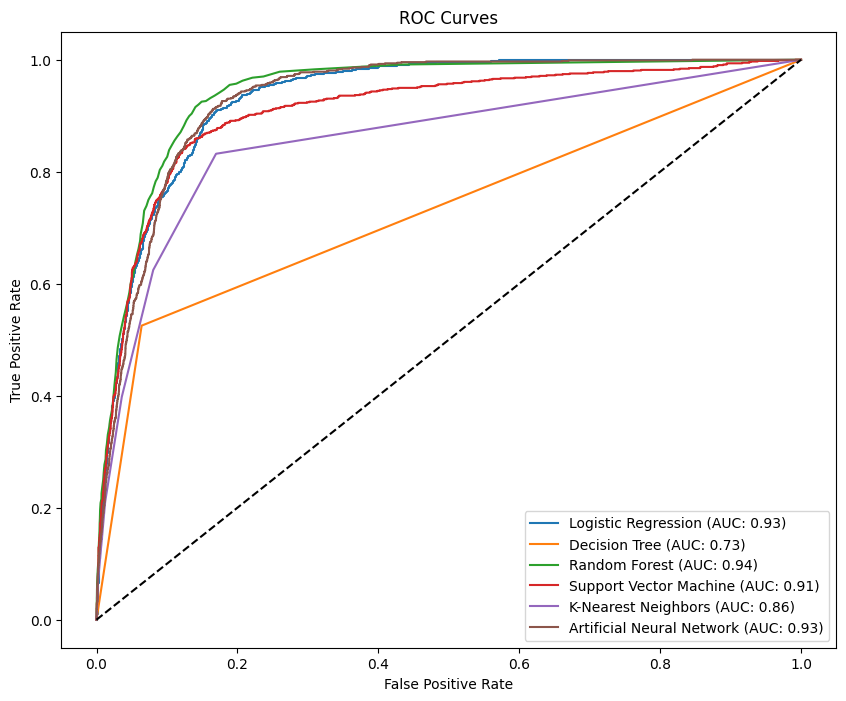

In [ ]:
# Plot ROC curves for each classifier
plt.figure(figsize=(10, 8))

for name, clf in classifiers.items():
    print(f"\n{name}:")
    y_prob, metrics = evaluate_classifier(clf, X_train, X_test, y_train, y_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC: {metrics['auc']:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend(loc='best')
plt.show()

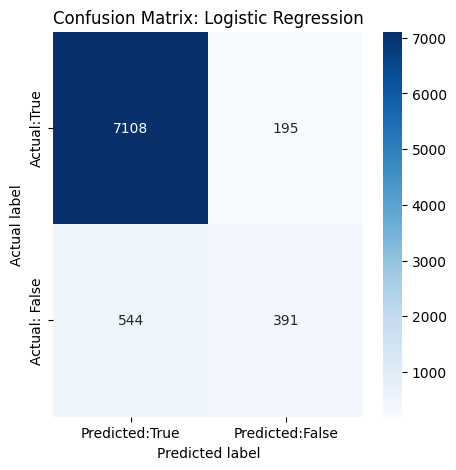

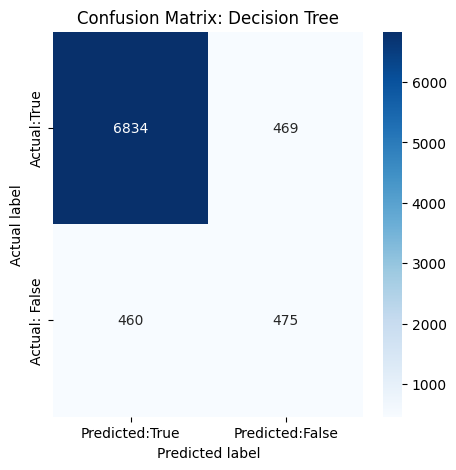

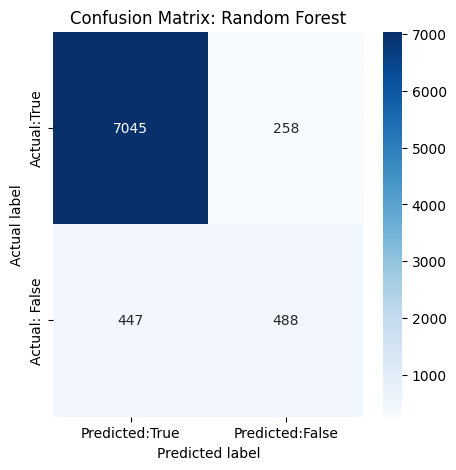

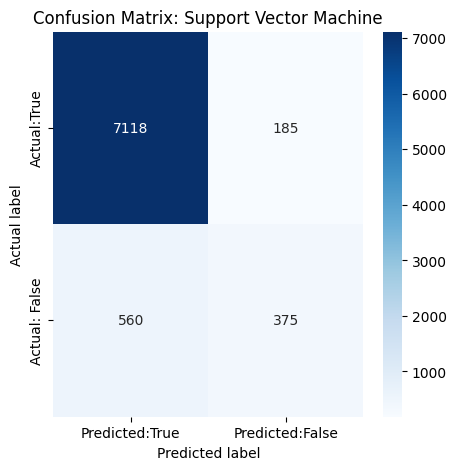

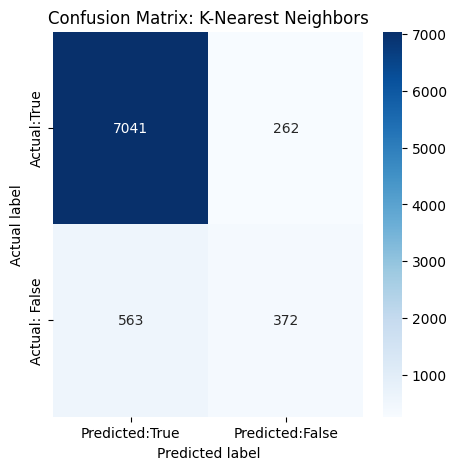

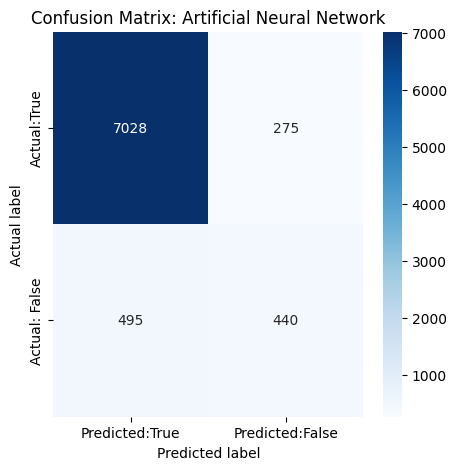

In [9]:
def evaluate_classifier2(clf, X_train, X_test, y_train, y_test):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    cm=confusion_matrix(y_test,y_pred)
    return cm

def plot_confusion_matrix(cm, name):
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted:True', 'Predicted:False'], yticklabels=['Actual:True', 'Actual: False'])
    plt.title(f'Confusion Matrix: {name}')
    plt.ylabel('Actual label')
    plt.xlabel('Predicted label')
    plt.show()


for name, clf in classifiers.items():
    # Plot confusion matrix
    cm = evaluate_classifier2(clf, X_train, X_test, y_train, y_test)
    plot_confusion_matrix(cm,name)